In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import re

folder = Path("Data/GBand/20260116_MF2_rotation_test/MLOG/")

class schema:
    #data = "data"
    freq = "freq"
    #freq_ = 'freq_data' 
    trans = 'data'
    angle = 'deg'
    #phase = 'phase_data' 
    #realdata = 'real_data' 
    #imagdata = 'imag_data' 
    #freqfit = 'freq_fit' 
    #transfit = 'trans_fit' 
    #realfit = 'real_fit' 
    #imagfit ='imag_fit' 
    #n = 'fit_n' 
    #loss = 'fit_los' 
    #nerr = 'fit_n_err'
    #losserr = 'fit_los_err'
    #transdiff = 'trans_diff'

def importfile(file):
    f = np.load(file)
    freq = f[schema.freq]
    data = f[schema.trans]
    angle = f[schema.angle]
    
    df = pd.DataFrame({schema.freq: freq, 
                       schema.trans: data,
                       schema.angle: angle})
    return df

# def get_mean_mlog():
#     folder = Path("Data/GBand/20260116_MF2_rotation_test/MLOG/")
#     integrated_transmission = []

#     for npz_file in folder.glob("*.npz"):
#         file = importfile(npz_file)

#         freq = file.iloc[:, 0].to_numpy()
#         trans = file.iloc[:, 1].to_numpy()
#         #plt.plot(freq, trans)
#         #plt.show()

#         integral = np.mean(trans)
#         integrated_transmission.append(integral)

#     return np.array(integrated_transmission)

def get_mean_transmission():
    folder = Path("Data/Transmission/")
    
    angles = []
    mean_trans = []

    for txt_file in folder.glob("*.txt"):
        match = re.search(r"([\d.]+)deg", txt_file.name) #angle from filename
        if not match:
            raise ValueError(f"Angle not found in filename: {txt_file.name}")
        angle = float(match.group(1))

        df = pd.read_csv(txt_file, sep=",")
        trans = df.iloc[:, 1].to_numpy()

        angles.append(angle)
        mean_trans.append(np.mean(trans))

    angles = np.array(angles)
    mean_trans = np.array(mean_trans)

    idx = np.argsort(angles)
    return angles[idx], mean_trans[idx]

def plot_peaks(plate):
    angles, transmission = get_mean_transmission()

    peaks, properties = find_peaks(transmission)

    plt.figure(figsize=(7, 5))
    plt.plot(angles, transmission, "k.", label="Mean transmission")
    plt.plot(angles, transmission, "k--")

    plt.plot(angles[peaks], transmission[peaks], "ro", label="Peaks")

    plt.title(f"Mean Transmission with Peaks - {plate}")
    plt.xlabel("Angle (deg)")
    plt.ylabel("Mean Transmission (dB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

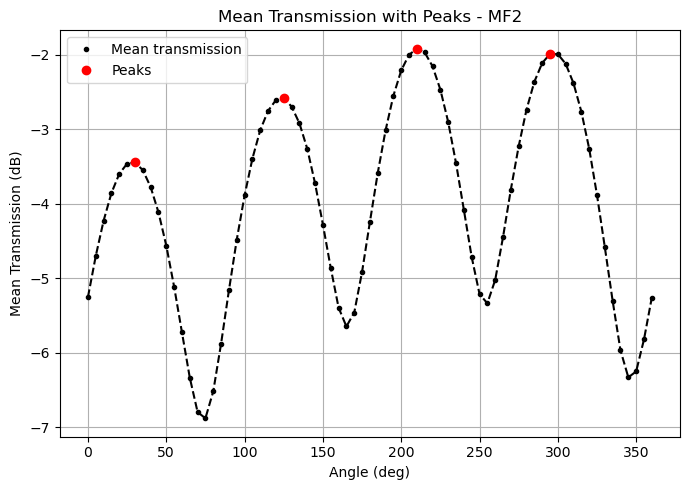

In [ ]:
plot_peaks("MF2")